In [15]:
import re
import nltk
import gensim
import gensim.corpora as corpora
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.models import TfidfModel
import os
from collections import Counter
import numpy as np
from gensim.models import Word2Vec

In [16]:
#LDA Demo

In [18]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kfang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kfang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kfang\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\kfang\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\kfang\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
file_path = "DemoData.txt" #do this separately for each decade
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

In [5]:
paragraphs = [p.strip() for p in text.split("\n") if p.strip()]
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [6]:
def get_wordnet_pos(word):
    """Map POS tag to WordNet POS"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

In [7]:
def preprocess(doc):
    doc = doc.lower()
    doc = re.sub(r'[^a-z\s]', '', doc)
    tokens = word_tokenize(doc)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens]
    return lemmatized

In [8]:
texts = [preprocess(p) for p in paragraphs]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
tfidf = TfidfModel(corpus, id2word=dictionary)

In [9]:
word_tfidf = {}
for doc in corpus:
    for word_id, freq in tfidf[doc]:
        word_tfidf[word_id] = word_tfidf.get(word_id, []) + [freq]

In [10]:
word_avg_tfidf = {word_id: sum(vals)/len(vals) for word_id, vals in word_tfidf.items()}
scores = list(word_avg_tfidf.values())
low_thresh = sorted(scores)[int(len(scores)*0.05)]
good_ids = {word_id for word_id, score in word_avg_tfidf.items()
            if low_thresh <= score }
filtered_texts = [[w for w in text if dictionary.token2id[w] in good_ids] for text in texts]
dictionary = corpora.Dictionary(filtered_texts)
corpus = [dictionary.doc2bow(text) for text in filtered_texts]

In [11]:
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,    
    random_state=42,
    passes=10,
    alpha='auto'
)

In [12]:
for idx, topic in lda_model.print_topics(num_words=15):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.014*"high" + 0.013*"urban" + 0.010*"state" + 0.010*"county" + 0.010*"racial" + 0.010*"disparity" + 0.009*"united" + 0.009*"density" + 0.008*"rate" + 0.008*"race" + 0.007*"low" + 0.006*"mortality" + 0.006*"ppr" + 0.006*"ruralurban" + 0.006*"status"
Topic 1: 0.018*"abstract" + 0.013*"day" + 0.010*"beneficiary" + 0.010*"individual" + 0.010*"area" + 0.009*"racialethnic" + 0.009*"black" + 0.009*"rpm" + 0.009*"policy" + 0.009*"food" + 0.008*"difference" + 0.008*"white" + 0.008*"disorder" + 0.008*"cancer" + 0.008*"treatment"
Topic 2: 0.022*"urban" + 0.021*"united" + 0.021*"state" + 0.012*"study" + 0.012*"race" + 0.010*"right" + 0.010*"policy" + 0.010*"population" + 0.010*"civil" + 0.009*"racial" + 0.008*"housing" + 0.008*"water" + 0.007*"city" + 0.007*"law" + 0.006*"political"
Topic 3: 0.015*"racial" + 0.010*"study" + 0.009*"neighborhood" + 0.009*"use" + 0.008*"urban" + 0.007*"state" + 0.007*"social" + 0.007*"resident" + 0.006*"community" + 0.006*"housing" + 0.006*"united" + 0.006*

In [13]:
topic_totals = np.zeros(lda_model.num_topics)
for doc_bow in corpus:
    topic_probs = lda_model.get_document_topics(doc_bow, minimum_probability=0)
    for topic_id, prob in topic_probs:
        topic_totals[topic_id] += prob

In [14]:
topic_percentages = topic_totals / len(corpus) * 100
print("\n--- Topic Distribution (Probabilistic Shares) ---")
for topic_id, perc in enumerate(topic_percentages):
    print(f"Topic {topic_id}: {perc:.2f}% of corpus")


--- Topic Distribution (Probabilistic Shares) ---
Topic 0: 21.46% of corpus
Topic 1: 17.65% of corpus
Topic 2: 23.16% of corpus
Topic 3: 15.45% of corpus
Topic 4: 22.28% of corpus


In [17]:
#W2V Demo

In [21]:
model = Word2Vec(texts, vector_size=100, window=5, min_count=2, workers=4)

In [22]:
word = "race"
if word in model.wv:
    top_similar_words = model.wv.most_similar(word, topn=25)
    print(f"Top 25 words similar to '{word}':")
    for rank, (similar_word, similarity) in enumerate(top_similar_words, start=1):
        print(f"{rank}. {similar_word} ({similarity:.4f})")
else:
    print(f"'{word}' is not in the vocabulary.")

Top 25 words similar to 'race':
1. urban (0.8804)
2. area (0.8801)
3. disparity (0.8731)
4. high (0.8726)
5. rural (0.8717)
6. racial (0.8697)
7. risk (0.8670)
8. difference (0.8669)
9. use (0.8634)
10. increase (0.8597)
11. policy (0.8578)
12. white (0.8545)
13. study (0.8521)
14. individual (0.8482)
15. incidence (0.8476)
16. rate (0.8457)
17. low (0.8457)
18. data (0.8435)
19. analysis (0.8416)
20. year (0.8407)
21. address (0.8393)
22. mortality (0.8387)
23. civil (0.8356)
24. gap (0.8353)
25. impact (0.8313)


In [23]:
#Cosine Similarity Demo

In [24]:
import gensim.downloader as api
from sklearn.metrics.pairwise import cosine_similarity

In [25]:
model = api.load("word2vec-google-news-300")

In [26]:
decades = {
    "1960s": ["ut","h","marcus","di","py","institute","may","social","quarterly","r","ep","mp","study","open","taeuber","journal","relation","vl","holden","deakin","wos","ti","ke","n","bp","santacruz","american","pt","affair","stegman","education","racial","kaplan","b","housing","planner","schoop","space","ej","af","au","er","policy","urban","brook","j","sn","raza"],
    "1970s": ["ep","j","bp","wos","vl","er","ut","pt","py","ti","af","urban","racial","di","sn","au","education","journal","change","study","school","university","detroit","l","law","ei","regional","anthropology","housing","segregation","dl","jm","dh","review","jf","e","ri","b","anonymous","science","american","g","residential","white","economics","neighborhood","rh","new","r","lawyer"],
    "1980s": ["er","af","sn","pd","ti","au","urban","ut","pt","vl","py","wos","bp","ep","j","race","di","study","review","class","journal","c","r","housing","affair","ei","neighborhood","economic","politics","education","jm","economics","political","k","weekly","l","segregation","galster","change","dec","planning","jt","association","league","e","anonymous","international","v","jun","research"],
    "1990s": ["housing","racial","planning","ti","change","af","difference","household","urban","policy","spatial","use","research","new","social","ab","segregation","group","discrimination","paper","public","state","city","result","american","study","model","article","class","characteristic","white","minority","economic","black","area","environmental","diversity","journal","community","evidence","ethnic","neighborhood","provide","income","concern","pattern","level","increase","sn","hispanic"],
    "2000s": ["public","racial","research","planning","article","housing","journal","ti","minority","development","policy","change","use","neighborhood","social","group","urban","park","american","study","new","diversity","space","community","af","ab","ethnic","city","pattern","economic","state","regional","ri","program","also","analysis","planner","literature","result","income","area","case","paper","segregation","oi","examines","local","place","work","association"],
    "2010s": ["american","planning","ti","journal","racial","research","housing","segregation","af","city","urban","new","regional","association","class","ab","ri","black","education","international","study","change","practice","neighborhood","use","state","minority","public","development","result","article","group","income","literature","white","analysis","also","sn","show","homeownership","increase","african","zone","oi","equity","pd","space","policy","understand","social"],
    "2020s": ["planning","journal","ti","af","american","black","research","practice","urban","planner","study","literature","community","association","experience","white","theory","oi","policy","justice","minority","education","racial","ab","united","housing","neighborhood","equity","ri","strategy","inequality","segregation","sn","problem","ethnic","analysis","finding","development","use","article","address","within","state","opportunity","ei","space","examine","among","youth","regional"]
}

In [27]:
decade_keys = list(decades.keys())
similarity_results = {}

In [28]:
for i in range(len(decade_keys) - 1):
    decade1 = decade_keys[i]
    decade2 = decade_keys[i + 1]
    
    vectors1 = [model[word] for word in decades[decade1] if word in model]
    vectors2 = [model[word] for word in decades[decade2] if word in model]
    
    if vectors1 and vectors2:
        avg_vector1 = np.mean(vectors1, axis=0).reshape(1, -1)
        avg_vector2 = np.mean(vectors2, axis=0).reshape(1, -1)
        similarity = cosine_similarity(avg_vector1, avg_vector2)[0][0]
    else:
        similarity = None 

    similarity_results[f"{decade1} → {decade2}"] = similarity

In [29]:
for transition, score in similarity_results.items():
    print(f"Semantic shift from {transition}: {score:.3f}")

Semantic shift from 1960s → 1970s: 0.940
Semantic shift from 1970s → 1980s: 0.946
Semantic shift from 1980s → 1990s: 0.637
Semantic shift from 1990s → 2000s: 0.939
Semantic shift from 2000s → 2010s: 0.948
Semantic shift from 2010s → 2020s: 0.946


In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [31]:
decade_vectors = {}
for decade, words in decades.items():
    vectors = [model[word] for word in words if word in model]
    if vectors:
        avg_vector = np.mean(vectors, axis=0)
        decade_vectors[decade] = avg_vector

In [32]:
pca = PCA(n_components=2)
coords = pca.fit_transform(list(decade_vectors.values()))

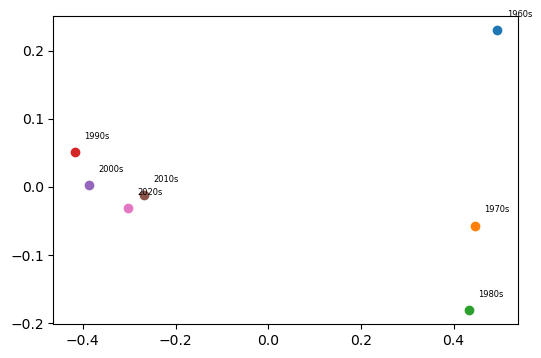

In [33]:
plt.figure(figsize=(6, 4))
for (decade, (x, y)) in zip(decade_vectors.keys(), coords):
    plt.scatter(x, y, label=decade)
    plt.text(x+0.02, y+0.02, decade, fontsize=6)